# Evaluate BinaryCombMaskGenerator

This notebook evaluates the `BinaryCombMaskGenerator` class with optional post-processing (closing and outlier suppression).

**Model:** combSegmentor.pth  
**Output:** Binary comb masks with optional post-processing

In [1]:
%load_ext autoreload
%autoreload 2

## Setup

In [ ]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from segmentation_restruct.comb_limitor import BinaryCombMaskGenerator
from segmentation_restruct.comb_limitor import CombMaskEvaluator

## Configuration

In [3]:
root_dir = Path().cwd().resolve().parent.parent
device = 'cuda'

# Test data paths
images_dir = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\images\test")
gt_dir = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\labels\test")

print(f"Model: combSegmentor")
print(f"Device: {device}")
print(f"Test images: {images_dir}")
print(f"Ground truth: {gt_dir}")

Model: combSegmentor
Device: cuda
Test images: E:\Bachelorarbeit\comb_limitation_dataset\images\test
Ground truth: E:\Bachelorarbeit\comb_limitation_dataset\labels\test


## Load Generator

**Post-processing options:**
- `apply_closing`: Fills small holes in the mask
- `apply_outlier_suppression`: Removes small isolated regions

In [10]:
# Initialize with post-processing enabled
generator = BinaryCombMaskGenerator(
    device=device,
    apply_closing=True,
    apply_outlier_suppression=True,
    closing_kernel_size=5,
    min_contour_area=2000
)

print("✓ Generator initialized successfully")
print(f"  Closing: {generator.apply_closing}")
print(f"  Outlier suppression: {generator.apply_outlier_suppression}")

✓ Generator initialized successfully
  Closing: True
  Outlier suppression: True


## Test on Single Image

In [11]:
# Get first test image
test_image = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\images\test\20240529_cam-2.png")

if not test_image.exists():
    test_images = sorted(images_dir.glob("*.png")) + sorted(images_dir.glob("*.jpg"))
    if test_images:
        test_image = test_images[0]
    else:
        raise FileNotFoundError(f"No images found in {images_dir}")

print(f"Testing with: {test_image.name}")

Testing with: 20240606_cam-3.png


In [12]:
# Generate mask
pred_mask = generator.generate_comb_mask(test_image)

print(f"Prediction shape: {pred_mask.shape}")
print(f"Unique values: {np.unique(pred_mask)}")
print(f"Comb coverage: {np.mean(pred_mask) * 100:.1f}%")

Prediction shape: (4608, 5312)
Unique values: [0 1]
Comb coverage: 60.6%


In [13]:
# Load input image and ground truth
input_img = cv2.imread(str(test_image), cv2.IMREAD_GRAYSCALE)

gt_path = gt_dir / test_image.name
if not gt_path.exists():
    gt_path = gt_dir / test_image.with_suffix('.png').name

if gt_path.exists():
    gt_mask = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
    gt_mask = (gt_mask > 0).astype(np.uint8)
    print(f"✓ Loaded ground truth: {gt_path.name}")
else:
    print(f"⚠ Ground truth not found: {gt_path}")
    gt_mask = None

✓ Loaded ground truth: 20240606_cam-3.png


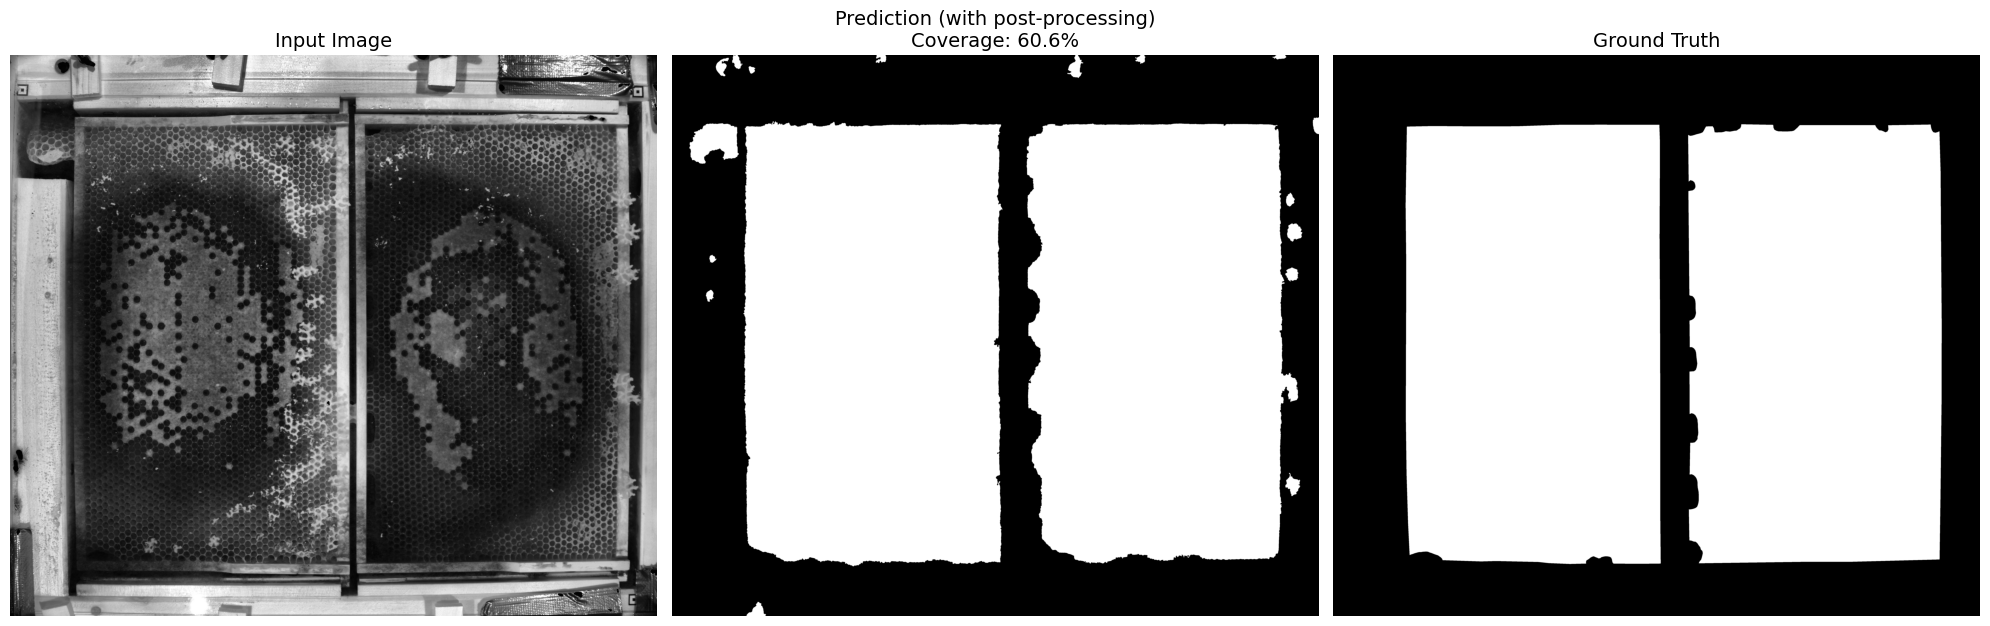

In [14]:
# Visualize: Input, Prediction, Ground Truth
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(input_img, cmap='gray')
axes[0].set_title('Input Image', fontsize=14)
axes[0].axis('off')

axes[1].imshow(pred_mask, cmap='gray')
axes[1].set_title(f'Prediction (with post-processing)\nCoverage: {np.mean(pred_mask)*100:.1f}%', fontsize=14)
axes[1].axis('off')

if gt_mask is not None:
    axes[2].imshow(gt_mask, cmap='gray')
    axes[2].set_title('Ground Truth', fontsize=14)
    axes[2].axis('off')
else:
    axes[2].text(0.5, 0.5, 'No Ground Truth', ha='center', va='center', fontsize=14)
    axes[2].axis('off')

plt.tight_layout()
plt.show()

## Evaluate Single Image


           BinaryCombMaskGenerator - Single Image           

Main Metrics:
Accuracy:    0.9775  (97.75%)
IoU:         0.9635  (96.35%)
Dice:        0.9814  (98.14%)
F1 Score:    0.9814  (98.14%)

Precision & Recall:
Precision:   0.9786  (97.86%)
Recall:      0.9842  (98.42%)
Specificity: 0.9674  (96.74%)

Confusion Matrix:
True Positives  (TP): 14,510,083
True Negatives  (TN): 9,417,373
False Positives (FP): 317,684
False Negatives (FN): 232,556
Total pixels:         24,477,696



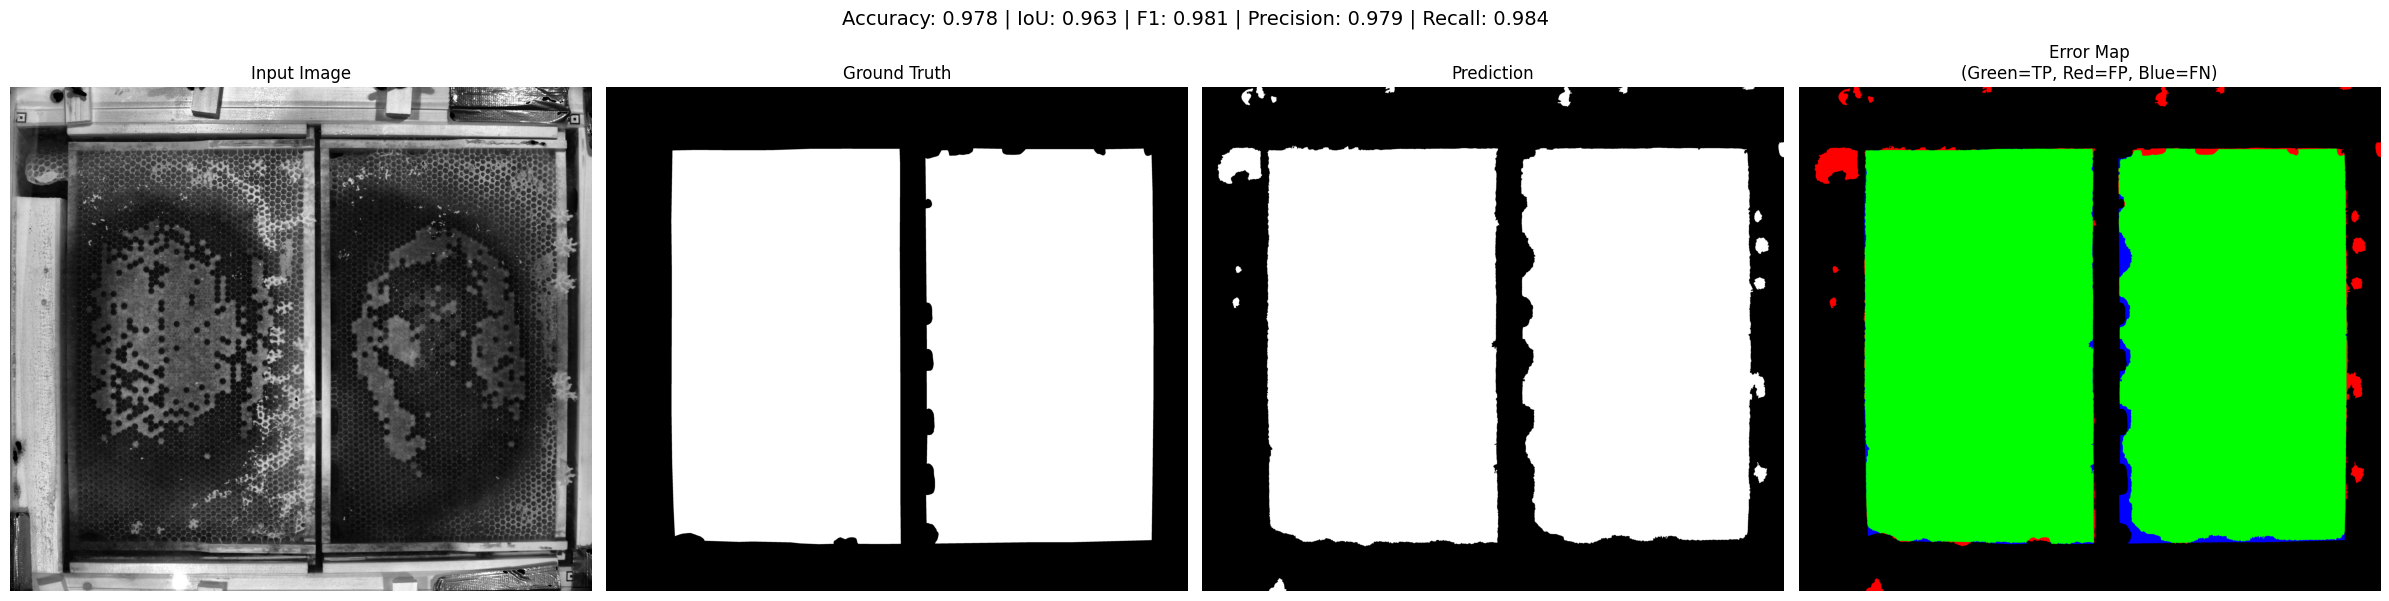

In [15]:
if gt_mask is not None:
    evaluator = CombMaskEvaluator()
    metrics = evaluator.evaluate(pred_mask, gt_mask)

    evaluator.print_metrics(metrics, title="BinaryCombMaskGenerator - Single Image")

    fig, axes = evaluator.visualize_prediction(
        pred_mask,
        gt_mask,
        input_image=input_img,
        show_metrics=True
    )
    plt.show()
else:
    print("⚠ Skipping evaluation - no ground truth available")

## Batch Processing and Evaluation

In [16]:
# Find all test images with ground truth
image_files = sorted(images_dir.glob("*.png")) + sorted(images_dir.glob("*.jpg"))
print(f"Found {len(image_files)} images to process")

predicted_masks = []
ground_truth_masks = []
input_images = []
image_names = []

print("\nProcessing images...")
for img_file in image_files:
    gt_file = gt_dir / img_file.name
    if not gt_file.exists():
        gt_file = gt_dir / img_file.with_suffix('.png').name

    if not gt_file.exists():
        print(f"Skipping {img_file.name} - no ground truth found")
        continue

    print(f"Processing {img_file.name}...")

    input_img = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)
    pred_mask = generator.generate_comb_mask(img_file)

    gt_mask = cv2.imread(str(gt_file), cv2.IMREAD_GRAYSCALE)
    gt_mask = (gt_mask > 0).astype(np.uint8)

    predicted_masks.append(pred_mask)
    ground_truth_masks.append(gt_mask)
    input_images.append(input_img)
    image_names.append(img_file.name)

print(f"\n✓ Processed {len(predicted_masks)} images successfully")

Found 4 images to process

Processing images...
Processing 20240606_cam-3.png...
Processing background_cam-0_20250719T012105.601863.038Z.png...
Processing background_cam-0_20250719T012105.601863.038Z.png...
Processing background_cam-3_20250705T043209.571836.965Z.png...
Processing background_cam-3_20250705T043209.571836.965Z.png...
Processing k_background_cam-1_20250816T104412.249021.386Z--20250816T104512.171084.576Z.png...
Processing k_background_cam-1_20250816T104412.249021.386Z--20250816T104512.171084.576Z.png...

✓ Processed 4 images successfully

✓ Processed 4 images successfully


## Batch Evaluation

In [17]:
evaluator = CombMaskEvaluator()

aggregate_metrics, per_image_metrics = evaluator.evaluate_batch_from_arrays(
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    image_names=image_names
)

print("\n" + "="*60)
print("BINARY COMB MASK GENERATOR - EVALUATION RESULTS")
print("="*60)
evaluator.print_metrics(aggregate_metrics, title="Aggregate Metrics")

print("\n" + "="*60)
print("Per-Image Results:")
print("="*60)
for metrics in per_image_metrics:
    print(f"\n{metrics['filename']}:")
    print(f"  IoU: {metrics['iou']:.4f}  |  Dice: {metrics['dice']:.4f}  |  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}  |  Recall: {metrics['recall']:.4f}")


BINARY COMB MASK GENERATOR - EVALUATION RESULTS

                     Aggregate Metrics                      

Aggregate Statistics (n=4 images):

  Main Metrics:
IoU:      0.9740 +/- 0.0075  (range: 0.9635 - 0.9819)
Dice/F1:  0.9868 +/- 0.0038  (range: 0.9814 - 0.9909)
Accuracy: 0.9831 +/- 0.0047  (range: 0.9775 - 0.9884)

  Precision & Recall:
Precision:   0.9836 +/- 0.0043  (range: 0.9786 - 0.9893)
Recall:      0.9900 +/- 0.0037  (range: 0.9842 - 0.9938)
Specificity: 0.9700 +/- 0.0086  (range: 0.9579 - 0.9812)

  Confusion Matrix Totals:
True Positives  (TP): 62,195,551  (avg: 15,548,888 per image)
True Negatives  (TN): 34,061,775  (avg: 8,515,444 per image)
False Positives (FP): 1,030,643  (avg: 257,661 per image)
False Negatives (FN): 622,815  (avg: 155,704 per image)
Total pixels:         97,910,784


Per-Image Results:

20240606_cam-3.png:
  IoU: 0.9635  |  Dice: 0.9814  |  Accuracy: 0.9775
  Precision: 0.9786  |  Recall: 0.9842

background_cam-0_20250719T012105.601863.038Z.png

## Save Results

In [18]:
date_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_name = f"binary_comb_mask_generator_{date_str}"

print(f"Run name: {run_name}")

saved_paths = evaluator.save_batch_results(
    aggregate_metrics=aggregate_metrics,
    per_image_metrics=per_image_metrics,
    output_dir=root_dir / "results",
    run_name=run_name,
    save_figure=True,
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    input_images=input_images,
    image_names=image_names
)

print("\n✓ Results saved:")
for key, path in saved_paths.items():
    print(f"  {key}: {path}")

Run name: binary_comb_mask_generator_2025-11-01_16-06-25
✓ Aggregate metrics saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\binary_comb_mask_generator_2025-11-01_16-06-25\aggregate_metrics.json
✓ Per-image metrics saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\binary_comb_mask_generator_2025-11-01_16-06-25\per_image_metrics.json
✓ Visualization saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\binary_comb_mask_generator_2025-11-01_16-06-25\visualization.png
✓ Summary saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\binary_comb_mask_generator_2025-11-01_16-06-25\summary.txt

All results saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\binary_comb_mask_generator_2025-11-01_16-06-25


✓ Results saved:
  aggregate: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inf

## Visualize Batch Results

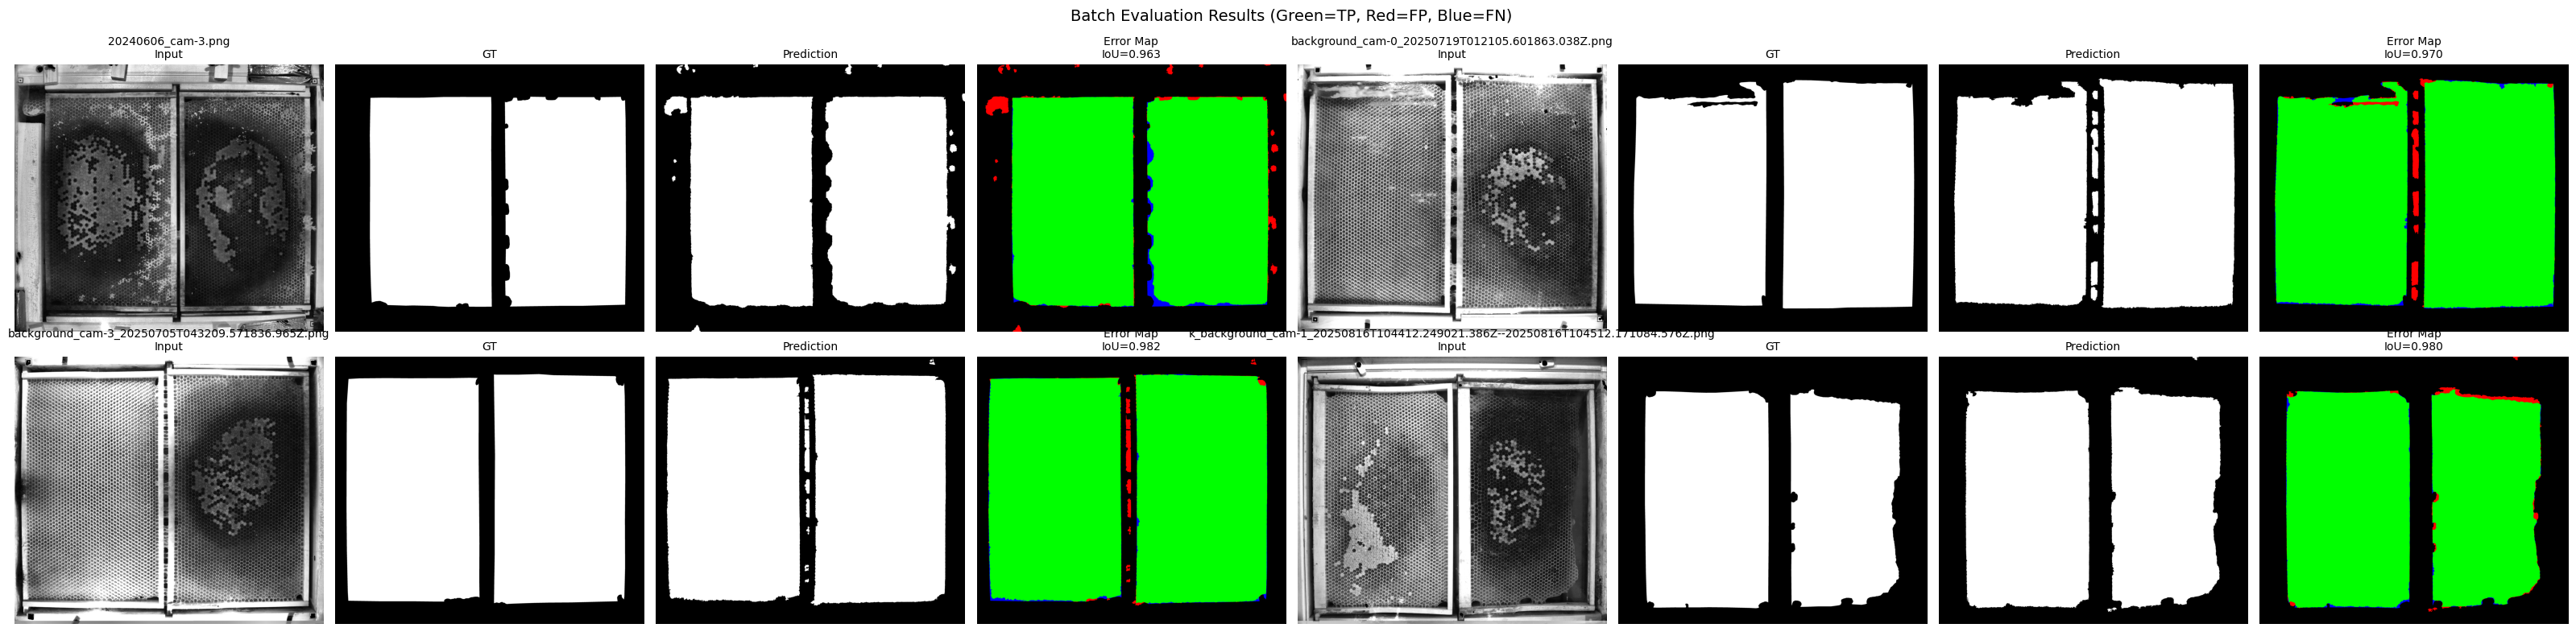

In [19]:
fig, axes = evaluator.visualize_batch(
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    image_names=image_names,
    input_images=input_images,
    max_cols=2
)
plt.show()

## Compare With/Without Post-Processing

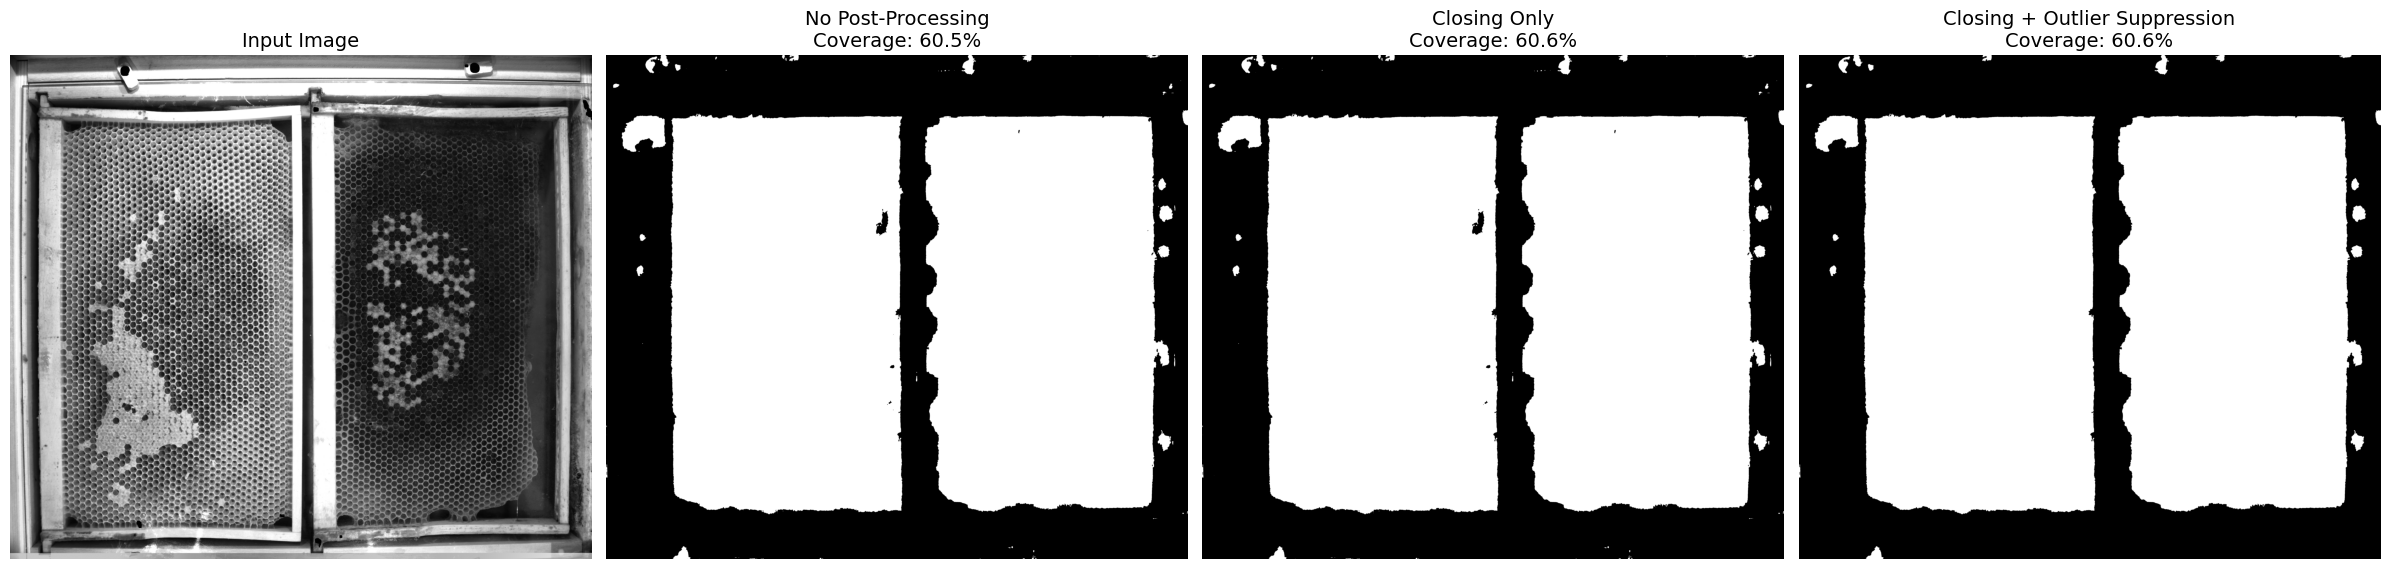

In [20]:
# Generate masks with different settings
generator_no_pp = BinaryCombMaskGenerator(device=device, apply_closing=False, apply_outlier_suppression=False)
generator_closing_only = BinaryCombMaskGenerator(device=device, apply_closing=True, apply_outlier_suppression=False)
generator_full = BinaryCombMaskGenerator(device=device, apply_closing=True, apply_outlier_suppression=True)

mask_no_pp = generator_no_pp.generate_comb_mask(test_image)
mask_closing = generator_closing_only.generate_comb_mask(test_image)
mask_full = generator_full.generate_comb_mask(test_image)

# Visualize comparison
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(input_img, cmap='gray')
axes[0].set_title('Input Image', fontsize=14)
axes[0].axis('off')

axes[1].imshow(mask_no_pp, cmap='gray')
axes[1].set_title(f'No Post-Processing\nCoverage: {np.mean(mask_no_pp)*100:.1f}%', fontsize=14)
axes[1].axis('off')

axes[2].imshow(mask_closing, cmap='gray')
axes[2].set_title(f'Closing Only\nCoverage: {np.mean(mask_closing)*100:.1f}%', fontsize=14)
axes[2].axis('off')

axes[3].imshow(mask_full, cmap='gray')
axes[3].set_title(f'Closing + Outlier Suppression\nCoverage: {np.mean(mask_full)*100:.1f}%', fontsize=14)
axes[3].axis('off')

plt.tight_layout()
plt.show()

## Summary

**Class:** BinaryCombMaskGenerator  
**Model:** combSegmentor.pth  
**Post-processing:** Configurable closing and outlier suppression  
**Evaluation:** Complete metrics saved to results folder